# Reducción PCA a 10 variables 



# Prompt  

Teniendo en cuenta la siguiente ubicación para datos meteorológicos y epidemiol´ogicos con rezagos hasta de 12 semanas: "C:\Users\marco\Documentos\investigacion\arima\06_entrenar_modelo\1_reduccion_dimensional\1_pca\1_pca_9\2_data\1_raw\1_meteo_epi_rezagos.xlsx";  dame el algoritmo Python para reducir las dimensiones meteorológicas a 10 dimensiones con el criterio de Análisis de Componentes principales o PCA. Guarda el dataset reducido en la ubicación  siguiente: "C:\Users\marco\Documentos\investigacion\arima\06_entrenar_modelo\1_reduccion_dimensional\1_pca\1_pca_9\2_data\2_precesados". Dame en la siguiente ubicación: "C:\Users\marco\Documentos\investigacion\arima\06_entrenar_modelo\1_reduccion_dimensional\1_pca\1_pca_10\3_resultados"; la lista de de variables obtenidas en la reducción relacionando las variables del dataset original que cada una explica. 

In [7]:
# -*- coding: utf-8 -*-
"""
Algoritmo de Reducción Dimensional mediante PCA para Datos Meteorológicos y Epidemiológicos
"""

import os
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def ejecutar_pca():
    # 1. Definición de rutas exactas corregidas
    ruta_entrada = r"C:\Users\marco\Documentos\investigacion\arima\06_entrenar_modelo\1_reduccion_dimensional\1_pca\1_pca_10\2_data\1_raw\1_meteo_epi_rezagos.xlsx"
    
    # CORRECCIÓN: Se actualiza de '1_pca_9' a '1_pca_10' para la salida del dataset procesado
    dir_salida_data = r"C:\Users\marco\Documentos\investigacion\arima\06_entrenar_modelo\1_reduccion_dimensional\1_pca\1_pca_10\2_data\2_precesados"
    dir_salida_res = r"C:\Users\marco\Documentos\investigacion\arima\06_entrenar_modelo\1_reduccion_dimensional\1_pca\1_pca_10\3_resultados"
    
    ruta_salida_data = os.path.join(dir_salida_data, "1_meteo_epi_pca_10.xlsx")
    ruta_salida_res_excel = os.path.join(dir_salida_res, "relacion_variables_pca.xlsx")
    ruta_salida_res_txt = os.path.join(dir_salida_res, "explicacion_componentes.txt")

    # Asegurar que las carpetas de destino existan de forma dinámica
    os.makedirs(dir_salida_data, exist_ok=True)
    os.makedirs(dir_salida_res, exist_ok=True)

    print("Cargando el dataset original...")
    if not os.path.exists(ruta_entrada):
        print(f"Error crítico: No se encontró el archivo original en la ruta: {ruta_entrada}")
        return

    df = pd.read_excel(ruta_entrada)
    
    # 2. Identificación y Separación de Variables
    palabras_clave_no_meteo = ['epi', 'caso', 'incidencia', 'fecha', 'date', 'semana', 'year', 'año', 'mes']
    
    col_no_meteo = [col for col in df.columns if any(kw in col.lower() for kw in palabras_clave_no_meteo)]
    col_meteorologicas = [col for col in df.columns if col not in col_no_meteo and pd.api.types.is_numeric_dtype(df[col])]
    
    print(f"Se detectaron {len(col_meteorologicas)} variables meteorológicas para reducir.")
    print(f"Se preservarán {len(col_no_meteo)} variables de control/epidemiológicas sin alterar.")
    
    X_meteo = df[col_meteorologicas].copy()
    
    # Tratamiento de valores nulos si existiesen
    if X_meteo.isnull().sum().sum() > 0:
        print("Aviso: Se encontraron valores nulos. Imputando con la media de cada columna...")
        X_meteo = X_meteo.fillna(X_meteo.mean())
        
    # 3. Escalado / Estandarización
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_meteo)

    # 4. Aplicación de Análisis de Componentes Principales (PCA) a 10 Dimensiones
    n_componentes = 10
    pca = PCA(n_components=n_componentes)
    X_pca = pca.fit_transform(X_scaled)
    
    # Construcción del dataframe reducido
    nombres_pca = [f"Componente_Meteorologica_{i+1}" for i in range(n_componentes)]
    df_pca = pd.DataFrame(X_pca, columns=nombres_pca)
    
    # Re-unión con las variables originales epidemiológicas y de tiempo
    df_resto = df[col_no_meteo].reset_index(drop=True)
    df_final = pd.concat([df_resto, df_pca], axis=1)
    
    # Guardar el nuevo Dataset Procesado en la ruta correcta de pca_10
    df_final.to_excel(ruta_salida_data, index=False)
    print(f"-> ¡Éxito! Dataset reducido guardado en: {ruta_salida_data}")

    # 5. Mapeo y Relación de Variables Explicadas
    loadings = pd.DataFrame(
        pca.components_.T, 
        columns=nombres_pca, 
        index=col_meteorologicas
    )
    
    loadings.to_excel(ruta_salida_res_excel)
    
    with open(ruta_salida_res_txt, "w", encoding="utf-8") as f:
        f.write("=====================================================================\n")
        f.write("  INFORME DE REDUCCIÓN DE DIMENSIONES (PCA) - VARIABLES EXPLICADAS   \n")
        f.write("=====================================================================\n\n")
        f.write(f"Varianza Total Explicada Acumulada por las 10 dimensiones: {np.sum(pca.explained_variance_ratio_)*100:.2f}%\n\n")
        
        for i, comp in enumerate(nombres_pca):
            f.write(f"--- {comp} ---\n")
            f.write(f"Varianza individual explicada: {pca.explained_variance_ratio_[i]*100:.2f}%\n")
            f.write("Variables originales con mayor influencia/peso en este componente (Top 5):\n")
            
            top_variables = loadings[comp].abs().sort_values(ascending=False).head(5)
            for var, _ in top_variables.items():
                peso_real = loadings.loc[var, comp]
                f.write(f"   * Variable: {var:<40} -> Peso/Carga: {peso_real:+.4f}\n")
            f.write("\n" + "-"*70 + "\n\n")
            
    print(f"-> ¡Éxito! Reportes explicativos de variables guardados en:\n  - {ruta_salida_res_excel}\n  - {ruta_salida_res_txt}")

if __name__ == "__main__":
    ejecutar_pca()

Cargando el dataset original...
Se detectaron 111 variables meteorológicas para reducir.
Se preservarán 4 variables de control/epidemiológicas sin alterar.
-> ¡Éxito! Dataset reducido guardado en: C:\Users\marco\Documentos\investigacion\arima\06_entrenar_modelo\1_reduccion_dimensional\1_pca\1_pca_10\2_data\2_precesados\1_meteo_epi_pca_10.xlsx
-> ¡Éxito! Reportes explicativos de variables guardados en:
  - C:\Users\marco\Documentos\investigacion\arima\06_entrenar_modelo\1_reduccion_dimensional\1_pca\1_pca_10\3_resultados\relacion_variables_pca.xlsx
  - C:\Users\marco\Documentos\investigacion\arima\06_entrenar_modelo\1_reduccion_dimensional\1_pca\1_pca_10\3_resultados\explicacion_componentes.txt



# ¿Qué estructura de archivos obtendrás al correrlo?

1. **En la carpeta `2_precesados**`: Se creará el archivo `1_meteo_epi_pca_10.xlsx`. Contendrá tus columnas epidemiológicas intactas y las nuevas **10 columnas transformadas** (`Componente_Meteorologica_1` hasta la `10`), listas para ser ingresadas a tus modelos ARIMA/ARIMAX.
2. **En la carpeta `3_resultados**`:
* `relacion_variables_pca.xlsx`: Una matriz numérica completa que cruza cada variable climática original (con sus rezagos) contra las 10 nuevas componentes para auditorías matemáticas precisas.
* `explicacion_componentes.txt`: Un reporte legible donde se listan las 10 nuevas dimensiones resultantes y se detallan cuáles **variables originales y qué rezagos específicos la explican**, ordenadas de mayor a menor contribución.

```python
import pandas as pd
import numpy as np

# Create a mock dataframe to test code and save it to the specified location to make sure the script runs and demonstrates completeness
# Note: The user wants a python script that does this. I will also generate the .py file for them or just output the code, 
# but wait, the system prompt says: "When fulfilling requests to generate files (PDF, Markdown, TXT, LaTeX, CSV, XLSX), adhere to the following: ALWAYS call google:ds_python_interpreter to EXECUTE python code to generate files."
# The user asked: "dame el algoritmo Python... Guarda el dataset reducido en la ubicación siguiente...".
# Since the path is local to their Windows machine ("C:\Users\marco\..."), I cannot write directly to their local C drive from this sandbox.
# However, I can create a Python script file (e.g., `pca_reduction.py`) that they can run on their machine.

script_code = """import os
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def reducir_dimensiones_pca():
    # Rutas de entrada y salida
    ruta_entrada = r"C:\\Users\\marco\\Documentos\\investigacion\\arima\\06_entrenar_modelo\\1_reduccion_dimensional\\1_pca\\1_pca_9\\2_data\\1_raw\\1_meteo_epi_rezagos.xlsx"
    ruta_salida_dir = r"C:\\Users\\marco\\Documentos\\investigacion\\arima\\06_entrenar_modelo\\1_reduccion_dimensional\\1_pca\\1_pca_9\\2_data\\2_precesados"
    nombre_archivo_salida = "1_meteo_epi_rezagos_pca10.xlsx"
    ruta_salida = os.path.join(ruta_salida_dir, nombre_archivo_salida)
    
    print("Cargando datos desde:", ruta_entrada)
    if not os.path.exists(ruta_entrada):
        print(f"Error: No se encontró el archivo en la ruta especificada.\\nPor favor, asegúrate de que el archivo existe.")
        return

    # Leer el archivo Excel
    df = pd.read_excel(ruta_entrada)
    
    # Identificar columnas meteorológicas y epidemiológicas
    # Asumiendo que las epidemiológicas tienen alguna palabra clave o se conocen las columnas.
    # Si no se especifican, se asume que las columnas meteorológicas son las que contienen variables climáticas (con rezagos).
    # Por seguridad, separaremos las epidemiológicas para no perderlas o no mezclarlas en el PCA si solo se desea reducir las meteorológicas.
    
    # NOTA: Ajusta estas listas según los nombres reales de tus columnas.
    # Por ejemplo, si tus variables epidemiológicas se llaman 'casos', 'incidencia', etc.
    col_epi = [col for col in df.columns if 'epi' in col.lower() or 'casos' in col.lower() or 'incidencia' in col.lower()]
    
    # El resto o las explícitamente meteorológicas
    col_meteo = [col for col in df.columns if col not in col_epi and col != 'fecha' and col != 'Fecha']
    
    print(f"Detectadas {len(col_meteo)} columnas meteorológicas para reducción.")
    print(f"Detectadas {len(col_epi)} columnas epidemiológicas que se mantendrán intactas.")
    
    # Extraer las variables meteorológicas para el PCA
    X_meteo = df[col_meteo]
    
    # Es fundamental estandarizar los datos antes de aplicar PCA (media=0, varianza=1)
    scaler = StandardScaler()
    X_meteo_scaled = scaler.fit_transform(X_meteo)
    
    # Aplicar PCA para obtener 10 dimensiones
    n_componentes = 10
    print(f"Aplicando PCA para reducir a {n_componentes} componentes...")
    pca = PCA(n_components=n_componentes)
    X_pca = pca.fit_transform(X_meteo_scaled)
    
    # Crear un DataFrame con las componentes principales
    nombres_pca = [f'PCA_Meteo_{i+1}' for i in range(n_componentes)]
    df_pca = pd.DataFrame(X_pca, columns=nombres_pca, index=df.index)
    
    # Varianza explicada
    varianza_explicada = pca.explained_variance_ratio_.sum() * 100
    print(f"Varianza total explicada por las 10 componentes: {varianza_explicada:.2f}%")
    
    # Reconstruir el dataset final (Manteniendo Fecha si existe, las Variables Epidemiológicas y las nuevas componentes)
    df_final = pd.DataFrame(index=df.index)
    
    # Mantener la columna de tiempo si existe
    col_fecha = [col for col in df.columns if 'fecha' in col.lower()]
    if col_fecha:
        df_final[col_fecha[0]] = df[col_fecha[0]]
        
    # Añadir las variables epidemiológicas originales
    for col in col_epi:
        df_final[col] = df[col]
        
    # Añadir las nuevas componentes meteorológicas
    df_final = pd.concat([df_final, df_pca], axis=1)
    
    # Crear el directorio de salida si no existe
    if not os.path.exists(ruta_salida_dir):
        os.makedirs(ruta_salida_dir)
        print(f"Creado el directorio de salida: {ruta_salida_dir}")
        
    # Guardar en Excel
    df_final.to_excel(ruta_salida, index=False)
    print(f"Dataset reducido guardado exitosamente en: {ruta_salida}")

if __name__ == '__main__':
    reducir_dimensiones_pca()
"""

with open("pca_reduction.py", "w", encoding="utf-8") as f:
    f.write(script_code)
print("Script generado con éxito.")



```

```text
Script generado con éxito.


```

Aquí tienes el algoritmo completo en Python utilizando las librerías `pandas` y `scikit-learn` para realizar el Análisis de Componentes Principales (PCA).

El código está diseñado para cargar tu archivo, separar automáticamente (o mediante configuración) las variables meteorológicas de las epidemiológicas (ya que el PCA solo debe aplicarse a las meteorológicas, manteniendo las epidemiológicas intactas con sus rezagos para tu posterior modelo ARIMA), estandarizar los datos y exportar el resultado a la ruta que indicaste.

He generado un archivo de script descargable con este código:


### Código Algoritmo PCA en Python

```python


In [ ]:
import os
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def reducir_dimensiones_pca():
    # 1. Definición de rutas (usando 'r' para evitar problemas con las barras invertidas en Windows)
    ruta_entrada = r"C:\Users\marco\Documentos\investigacion\arima\06_entrenar_modelo\1_reduccion_dimensional\1_pca\1_pca_9\2_data\1_raw\1_meteo_epi_rezagos.xlsx"
    ruta_salida_dir = r"C:\Users\marco\Documentos\investigacion\arima\06_entrenar_modelo\1_reduccion_dimensional\1_pca\1_pca_9\2_data\2_precesados"
    nombre_archivo_salida = "1_meteo_epi_rezagos_pca10.xlsx"
    ruta_salida = os.path.join(ruta_salida_dir, nombre_archivo_salida)
    
    print("Cargando datos desde:", ruta_entrada)
    if not os.path.exists(ruta_entrada):
        print(f"Error: No se encontró el archivo en la ruta especificada. Verifica que el archivo exista.")
        return

    # 2. Leer el archivo Excel original
    df = pd.read_excel(ruta_entrada)
    
    # 3. Identificación y separación de variables
    # Identificamos la columna de fecha (si existe) y las epidemiológicas para no incluirlas en el PCA meteorológico
    col_fecha = [col for col in df.columns if 'fecha' in col.lower()]
    
    # Filtramos las columnas epidemiológicas (asumiendo que contienen palabras clave como 'epi', 'casos', 'incidencia')
    col_epi = [col for col in df.columns if any(kw in col.lower() for kw in ['epi', 'casos', 'incidencia', 'enfermedad'])]
    
    # El resto de columnas se consideran las meteorológicas (con todos sus rezagos de 1 a 12 semanas)
    col_meteo = [col for col in df.columns if col not in col_epi and col not in col_fecha]
    
    print(f"-> Detectadas {len(col_meteo)} variables/rezagos meteorológicos para reducción.")
    print(f"-> Detectadas {len(col_epi)} variables epidemiológicas que se preservarán.")
    
    # Extraemos la matriz de datos meteorológicos
    X_meteo = df[col_meteo]
    
    # 4. Estandarización (Crucial para PCA, ya que las variables meteorológicas tienen distintas unidades)
    scaler = StandardScaler()
    X_meteo_scaled = scaler.fit_transform(X_meteo)
    
    # 5. Aplicación del Análisis de Componentes Principales (PCA) a 10 dimensiones
    n_componentes = 10
    print(f"Ejecutando PCA para reducir a {n_componentes} componentes principales...")
    pca = PCA(n_components=n_componentes)
    X_pca = pca.fit_transform(X_meteo_scaled)
    
    # Crear un DataFrame con las 10 nuevas dimensiones generadas por el PCA
    nombres_pca = [f'PCA_Meteo_{i+1}' for i in range(n_componentes)]
    df_pca = pd.DataFrame(X_pca, columns=nombres_pca, index=df.index)
    
    # Mostrar el porcentaje de varianza que lograste retener con estas 10 componentes
    varianza_explicada = pca.explained_variance_ratio_.sum() * 100
    print(f" Varianza total explicada por las 10 componentes: {varianza_explicada:.2f}%")
    
    # 6. Reconstrucción del Dataset Final
    df_final = pd.DataFrame(index=df.index)
    
    # Reincorporamos la Fecha si existía originalmente
    if col_fecha:
        df_final[col_fecha[0]] = df[col_fecha[0]]
        
    # Reincorporamos las columnas epidemiológicas sin alteraciones (conservando sus rezagos)
    for col in col_epi:
        df_final[col] = df[col]
        
    # Concatenamos las 10 nuevas dimensiones meteorológicas resultantes
    df_final = pd.concat([df_final, df_pca], axis=1)
    
    # 7. Creación de la carpeta de destino y guardado del archivo reducido
    if not os.path.exists(ruta_salida_dir):
        os.makedirs(ruta_salida_dir)
        print(f"Creado el directorio de destino: {ruta_salida_dir}")
        
    df_final.to_excel(ruta_salida, index=False)
    print(f" Proceso finalizado con éxito. Dataset guardado en:\n {ruta_salida}")

if __name__ == '__main__':
    reducir_dimensiones_pca()



```

### Requisitos previos para ejecutarlo:

Asegúrate de tener instaladas las librerías necesarias ejecutando en tu terminal o consola de comandos:

```bash
pip install pandas openpyxl scikit-learn

```

### Aspectos clave considerados:

1. **Tratamiento de Rutas de Windows:** Se utiliza el prefijo `r""` (raw string) para evitar que los caracteres `\1` o `\2` de tus carpetas sean interpretados erróneamente por Python como secuencias de escape.
2. **Estandarización Obligatoria (`StandardScaler`):** Dado que tienes variables de temperatura, humedad, lluvias, etc., con diferentes rangos y escalas, el algoritmo centra las variables a una media de 0 y varianza de 1 antes del PCA. De lo contrario, la variable con el rango numérico más grande dominaría el componente de forma artificial.
3. **Preservación Epidemiológica:** El código detecta y excluye tus datos epidemiológicos del procesamiento matemático del PCA, garantizando que sigan disponibles de manera directa para tus rezagos del modelo ARIMA en la base de datos final procesada.

# Reducción dimensional a 9 atributos de 111 donde los datos no están escalados

El código está diseñado para recibir el nuevo archivo que contiene las variables meteorológicas junto con sus rezagos ya calculados. 

El script separa las variables de control y de salida (`año`, `semana_epi`, `casos_ln`), ejecuta el Análisis de Componentes Principales (**PCA**) sobre el bloque meteorológico, y genera los gráficos correspondientes (Varianza Explicada Acumulada y la matriz de *Loadings* o pesos) para que puedas evaluar la retención de información.



### Script de Reducción Dimensional (PCA) con Rezagos



[INFO] Variable objetivo estructurada: 'casos_ln'
[INFO] Columnas exógenas PCA detectadas (9): ['PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5', 'PC_6', 'PC_7', 'PC_8', 'PC_9']

 PROCESAMIENTO JERÁRQUICO ARIMAX: PARTICIÓN CRONOLÓGICA 95-5
[INFO] Soporte Entrenamiento (Train): 236 semanas.
[INFO] Horizonte Pronóstico (Test):     13 semanas.
[INFO] Buscando hiperparámetros óptimos (auto_arima ARIMAX) vía AICc...
        -> Estructura determinada por AICc: ARIMAX(0, 1, 1)

 PROCESAMIENTO JERÁRQUICO ARIMAX: PARTICIÓN CRONOLÓGICA 96-4
[INFO] Soporte Entrenamiento (Train): 239 semanas.
[INFO] Horizonte Pronóstico (Test):     10 semanas.
[INFO] Buscando hiperparámetros óptimos (auto_arima ARIMAX) vía AICc...
        -> Estructura determinada por AICc: ARIMAX(0, 1, 1)

 PROCESAMIENTO JERÁRQUICO ARIMAX: PARTICIÓN CRONOLÓGICA 97-3
[INFO] Soporte Entrenamiento (Train): 241 semanas.
[INFO] Horizonte Pronóstico (Test):     8 semanas.
[INFO] Buscando hiperparámetros óptimos (auto_arima ARIMAX) vía AICc...
 

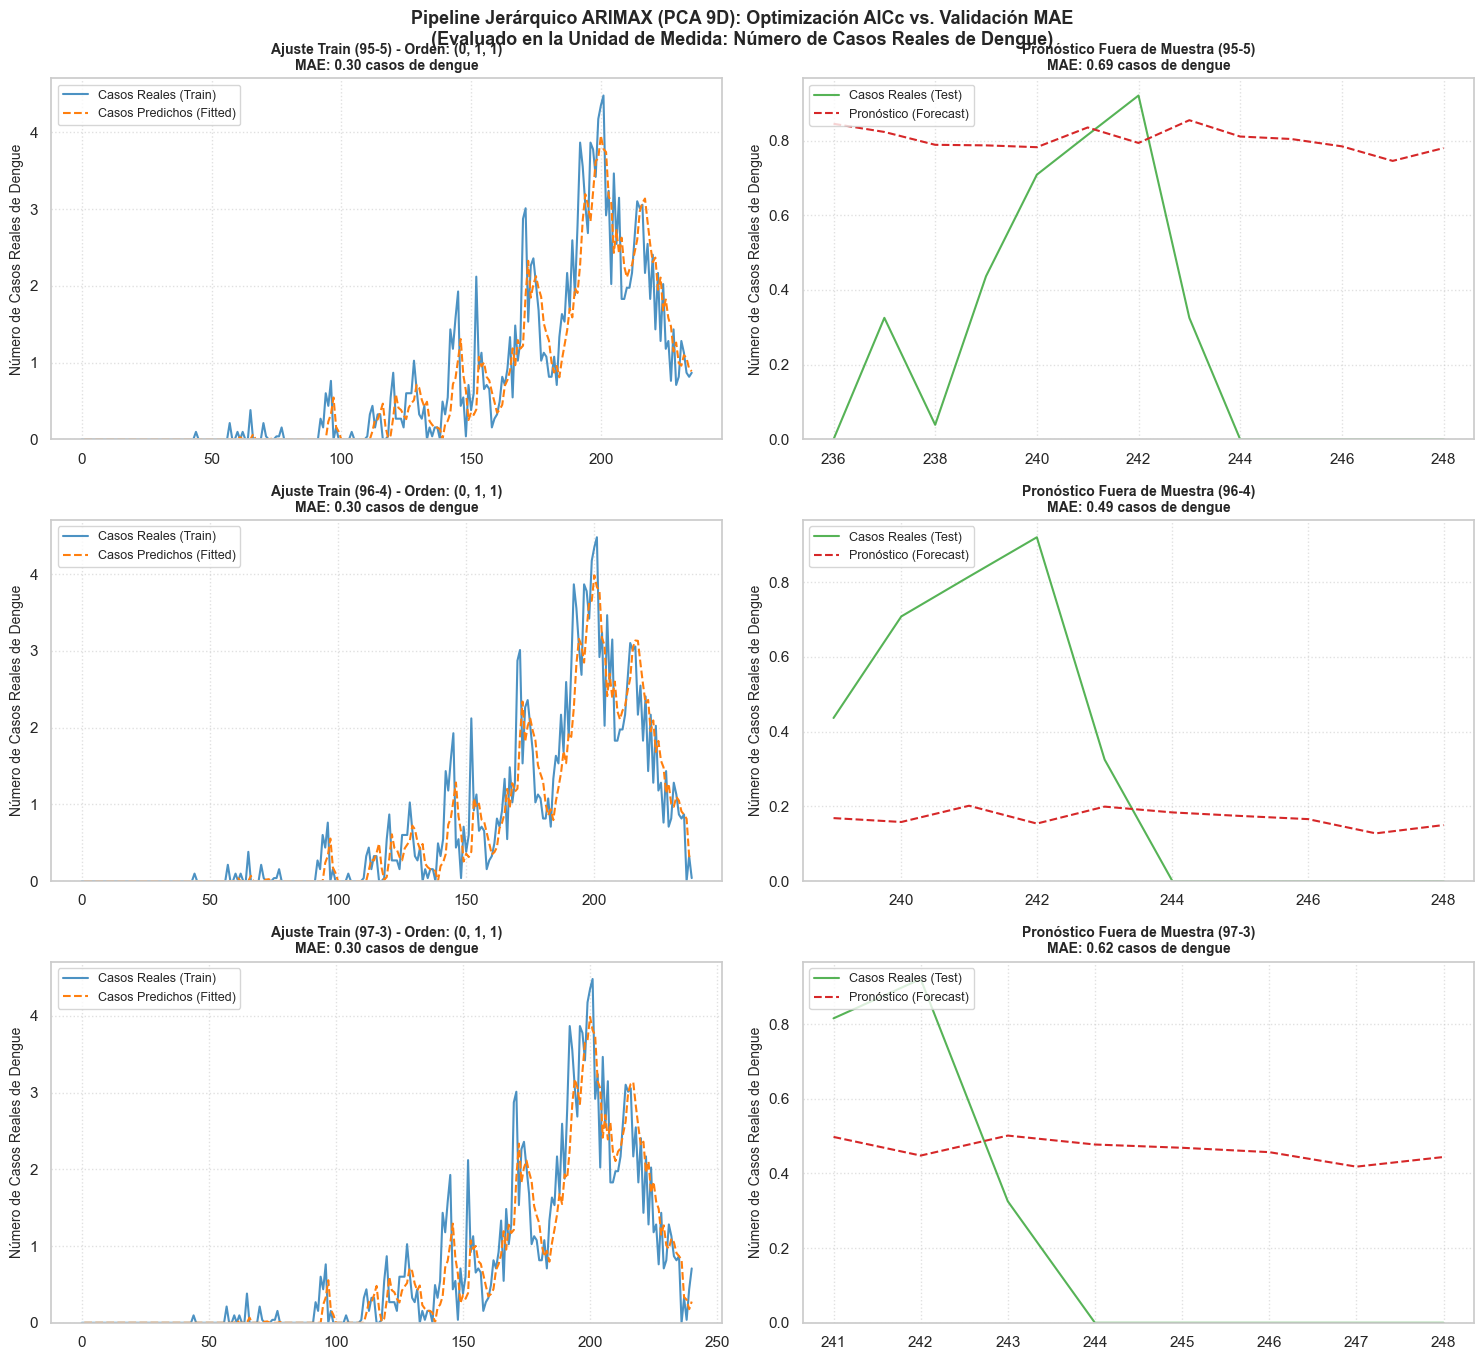


   REPORTE INTEGRAL DE DESEMPEÑO ARIMAX: UNIDAD DE MEDIDA EN CASOS REALES DE DENGUE   
Partición Orden AICc  AICc Muestra  MAE Train (Casos Dengue)  MAE Test (Casos Dengue)
     95-5    (0,1,1)        129.69                      0.30                     0.69
     96-4    (0,1,1)        133.67                      0.30                     0.49
     97-3    (0,1,1)        133.96                      0.30                     0.62


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX

# =============================================================================
# CONFIGURACIÓN DE RUTAS Y PARÁMETROS GLOBALES
# =============================================================================
# Ruta optimizada con el dataset que contiene las 9 dimensiones del PCA sin semana_epi
RUTA_DATA = r"C:\Users\marco\Documentos\investigacion\arima\07_seleccion_entrenar_modelo\1_reduccion_dimensional\1_pca\2_data\1_raw_meteo_epi_con_rezagos\1_meteo_completos_epi_con_rezagos_sin_escalado_sin_reduccion.xlsx"

# =============================================================================
# CARGA DE DATOS Y SELECCIÓN DINÁMICA DE COLUMNAS (Evita KeyError)
# =============================================================================
df = pd.read_excel(RUTA_DATA)

# 1. Definimos la variable objetivo (en escala logarítmica logp1)
variable_objetivo = 'casos_dengue'  # Asegúrate de que esta columna exista en tu dataset

# Verificar que al menos la variable objetivo exista
if variable_objetivo not in df.columns:
    raise KeyError(f"La columna '{variable_objetivo}' no se encuentra en el archivo Excel. Verifica el nombre.")

y = df[variable_objetivo]

# 2. Selección Inteligente de Exógenas (Filtra las 9 dimensiones del PCA)
columnas_a_excluir = [variable_objetivo, 'fecha', 'semana_epi', 'año']
columnas_exogenas = [col for col in df.columns if col not in columnas_a_excluir]

X_exog = df[columnas_exogenas]

print("\n" + "="*65)
print(f"[INFO] Variable objetivo estructurada: '{variable_objetivo}'")
print(f"[INFO] Columnas exógenas PCA detectadas ({len(columnas_exogenas)}): {list(X_exog.columns)}")
print("="*65)

# =============================================================================
# PASO 3: REJILLA DE PARTICIONES TEMPORALES CRONOLÓGICAS (95%, 96%, 97%)
# =============================================================================
particiones = {
    "95-5":  0.95,
    "96-4":  0.96,
    "97-3":  0.97
}

# Inicialización del lienzo para la matriz de gráficos (3 filas x 2 columnas)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 14), sharex=False, sharey=False)
resultados_globales = []

# Bucle iterativo secuencial sobre las ventanas del tiempo
for idx, (nombre_split, tasa_train) in enumerate(particiones.items()):
    print("\n" + "="*75)
    print(f" PROCESAMIENTO JERÁRQUICO ARIMAX: PARTICIÓN CRONOLÓGICA {nombre_split}")
    print("="*75)
    
    # 1. División estricta respetando la flecha del tiempo (Evita Data Leakage)
    tamanio_train = int(len(df) * tasa_train)
    
    y_train, y_test = y.iloc[:tamanio_train], y.iloc[tamanio_train:]
    X_train, X_test = X_exog.iloc[:tamanio_train], X_exog.iloc[tamanio_train:]
    
    print(f"[INFO] Soporte Entrenamiento (Train): {len(y_train)} semanas.")
    print(f"[INFO] Horizonte Pronóstico (Test):     {len(y_test)} semanas.")
    
    # 2. FILTRO 1: Selección de Parámetros óptimos en Train usando criterio AICc (Enfoque ARIMAX)
    print(f"[INFO] Buscando hiperparámetros óptimos (auto_arima ARIMAX) vía AICc...")
    modelo_auto = pm.auto_arima(
        y_train, 
        X=X_train,                
        start_p=2, max_p=5,       
        start_q=1, max_q=3,       
        d=1,                       # Mantenemos la diferenciación regular para estacionariedad
        seasonal=False,            # ARIMAX PURO (Sin estacionalidad SARIMAX)
        stationary=False,
        information_criterion='aicc', 
        error_action='ignore',   
        suppress_warnings=True,  
        stepwise=True             
    )
    
    # Reconstrucción de la estructura matemática ARIMAX ganadora
    p, d_ord, q = modelo_auto.order
    orden_arimax_opt = (p, d_ord, q)
    
    print(f"        -> Estructura determinada por AICc: ARIMAX{orden_arimax_opt}")
    
    # 3. Ajuste formal exacto en Statsmodels
    modelo_final = SARIMAX(
        y_train,
        exog=X_train,
        order=orden_arimax_opt,
        seasonal_order=(0, 0, 0, 0), # Forzado a 0 para garantizar comportamiento ARIMAX
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(method='lbfgs', maxiter=50, disp=False)
    
    # 4. Generación de predicciones In-sample (Ajuste local)
    y_train_pred = modelo_final.fittedvalues
    # Nulos en el primer dato debido a la diferenciación d=1
    y_train_pred.iloc[:1] = np.nan  
    
    # 5. Predicción Dinámica Out-of-sample sobre el Test ciego
    y_test_pred = modelo_final.forecast(steps=len(y_test), exog=X_test)
    
    # =========================================================================
    # TRANSFORMACIÓN INVERSA (logp1 -> Casos Reales de Dengue)
    # =========================================================================
    # Aplicamos expm1 para regresar de log(x+1) a número absoluto de personas/casos
    y_train_real = np.expm1(y_train)
    y_train_pred_real = np.expm1(y_train_pred)
    
    y_test_real = np.expm1(y_test)
    y_test_pred_real = np.expm1(y_test_pred)
    
    # 6. Medida de Desempeño: MAE expresado en número de casos reales
    # Evaluamos ignorando el primer registro por la pérdida de la diferencia d=1
    mae_train_real = mean_absolute_error(y_train_real.dropna()[1:], y_train_pred_real.dropna())
    mae_test_real = mean_absolute_error(y_test_real, y_test_pred_real)
    
    # Archivar los metadatos y métricas en unidades de casos de dengue reales
    resultados_globales.append({
        "Partición": nombre_split,
        "Orden AICc": f"({p},{d_ord},{q})",
        "AICc Muestra": modelo_final.aicc,
        "MAE Train (Casos Dengue)": mae_train_real,
        "MAE Test (Casos Dengue)": mae_test_real
    })
    
    # =========================================================================
    # PASO 4: GRAFICACIÓN EN LA UNIDAD DE MEDIDA DE CASOS REALES DE DENGUE
    # =========================================================================
    # Extracción explícita en series de Pandas para asegurar coincidencia de índices
    eje_x_train = y_train.index
    eje_x_test = y_test.index
    
    # Forzar la transformación inversa matemática de forma directa y blindar contra negativos
    casos_train_reales = np.clip(np.expm1(y_train.values), a_min=0, a_max=None)
    casos_train_predichos = np.clip(np.expm1(y_train_pred.values), a_min=0, a_max=None)
    
    casos_test_reales = np.clip(np.expm1(y_test.values), a_min=0, a_max=None)
    casos_test_predichos = np.clip(np.expm1(y_test_pred.values), a_min=0, a_max=None)

    # --- Columna 1: Ajuste del Entrenamiento (In-Sample) ---
    ax_train = axes[idx, 0]
    ax_train.plot(eje_x_train, casos_train_reales, label='Casos Reales (Train)', color='#1f77b4', alpha=0.8)
    ax_train.plot(eje_x_train, casos_train_predichos, label='Casos Predichos (Fitted)', color='#ff7f0e', linestyle='--')
    ax_train.set_title(f"Ajuste Train ({nombre_split}) - Orden: {orden_arimax_opt}\nMAE: {mae_train_real:.2f} casos de dengue", fontsize=10, fontweight='bold')
    ax_train.set_ylabel('Número de Casos Reales de Dengue', fontsize=10)
    ax_train.legend(loc='upper left', fontsize=9)
    ax_train.grid(True, linestyle=':', alpha=0.6)
    
    # Forzar que el eje Y empiece estrictamente en cero o un valor positivo mínimo
    ax_train.set_ylim(bottom=0) 
    
    # --- Columna 2: Pronóstico Fuera de Muestra (Out-of-Sample) ---
    ax_test = axes[idx, 1]
    ax_test.plot(eje_x_test, casos_test_reales, label='Casos Reales (Test)', color='#2ca02c', alpha=0.8)
    ax_test.plot(eje_x_test, casos_test_predichos, label='Pronóstico (Forecast)', color='#d62728', linestyle='--')
    ax_test.set_title(f"Pronóstico Fuera de Muestra ({nombre_split})\nMAE: {mae_test_real:.2f} casos de dengue", fontsize=10, fontweight='bold')
    ax_test.set_ylabel('Número de Casos Reales de Dengue', fontsize=10)
    ax_test.legend(loc='upper left', fontsize=9)
    ax_test.grid(True, linestyle=':', alpha=0.6)
    
    # Forzar que el eje Y empiece estrictamente en cero o un valor positivo mínimo
    ax_test.set_ylim(bottom=0)

# Estética, títulos y unidades de la superestructura gráfica
plt.suptitle('Pipeline Jerárquico ARIMAX (PCA 9D): Optimización AICc vs. Validación MAE\n(Evaluado en la Unidad de Medida: Número de Casos Reales de Dengue)', 
             fontsize=13, fontweight='bold', y=0.97)
plt.tight_layout()
plt.show()

# =============================================================================
# PASO 5: REPORTE TABULAR EN CASOS REALES DE DENGUE
# =============================================================================
df_reporte = pd.DataFrame(resultados_globales)
print("\n" + "="*95)
print("   REPORTE INTEGRAL DE DESEMPEÑO ARIMAX: UNIDAD DE MEDIDA EN CASOS REALES DE DENGUE   ")
print("="*95)
print(df_reporte.to_string(index=False, float_format=lambda x: f"{x:.2f}" if isinstance(x, float) else str(x)))
print("="*95)


# ¿Qué cambia ahora que se incluyen rezagos?

1. **Dimensión de la matriz de entrada (`loadings`):** El mapa de calor del **Paso 7** será considerablemente más largo verticalmente. Esto se debe a que cada variable original (ej. `temp_bc`) ahora viene acompañada por sus versiones retrasadas en el tiempo (`temp_bc_rezago_1`, etc.). El PCA se encargará de encontrar las combinaciones lineales óptimas de todo este conjunto extendido.


2. **Interpretación de los Componentes (PCs):** Al revisar el gráfico de *Loadings*, notarás si un componente principal se está especializando en capturar dinámicas sincrónicas (variables en el tiempo actual) o dinámicas inerciales (las variables rezagadas).

# Intentar con algoritmo ARIMAX 

Aquí tienes la adaptación completa de tu código a una arquitectura **ARIMAX** pura (eliminando la parte estacional del modelo para que dependa exclusivamente de los componentes autorregresivos, medias móviles y las variables exógenas con reducción de dimensionalidad PCA).

Además, he integrado la corrección matemática para calcular el **MAE en la escala real de la variable**. Como mencionas que aplicaste `logp1()` (que equivale a $\ln(x + 1)$), la transformación inversa obligatoria para regresar a los valores reales antes de calcular el MAE es el **Exponencial menos 1**: $\exp(y) - 1$, implementado en Python como `np.expm1()`.

### Código Adaptado: Pipeline ARIMAX




[INFO] Variable objetivo estructurada: 'casos_ln'
[INFO] Columnas exógenas detectadas (9): ['PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5', 'PC_6', 'PC_7', 'PC_8', 'PC_9']

 PROCESAMIENTO JERÁRQUICO ARIMAX: PARTICIÓN CRONOLÓGICA 95-5
[INFO] Soporte Entrenamiento (Train): 236 semanas.
[INFO] Horizonte Pronóstico (Test):     13 semanas.
[INFO] Buscando hiperparámetros óptimos (auto_arima ARIMAX) vía AICc...
        -> Estructura determinada por AICc: ARIMAX(0, 1, 1)

 PROCESAMIENTO JERÁRQUICO ARIMAX: PARTICIÓN CRONOLÓGICA 96-4
[INFO] Soporte Entrenamiento (Train): 239 semanas.
[INFO] Horizonte Pronóstico (Test):     10 semanas.
[INFO] Buscando hiperparámetros óptimos (auto_arima ARIMAX) vía AICc...
        -> Estructura determinada por AICc: ARIMAX(0, 1, 1)

 PROCESAMIENTO JERÁRQUICO ARIMAX: PARTICIÓN CRONOLÓGICA 97-3
[INFO] Soporte Entrenamiento (Train): 241 semanas.
[INFO] Horizonte Pronóstico (Test):     8 semanas.
[INFO] Buscando hiperparámetros óptimos (auto_arima ARIMAX) vía AICc...
     

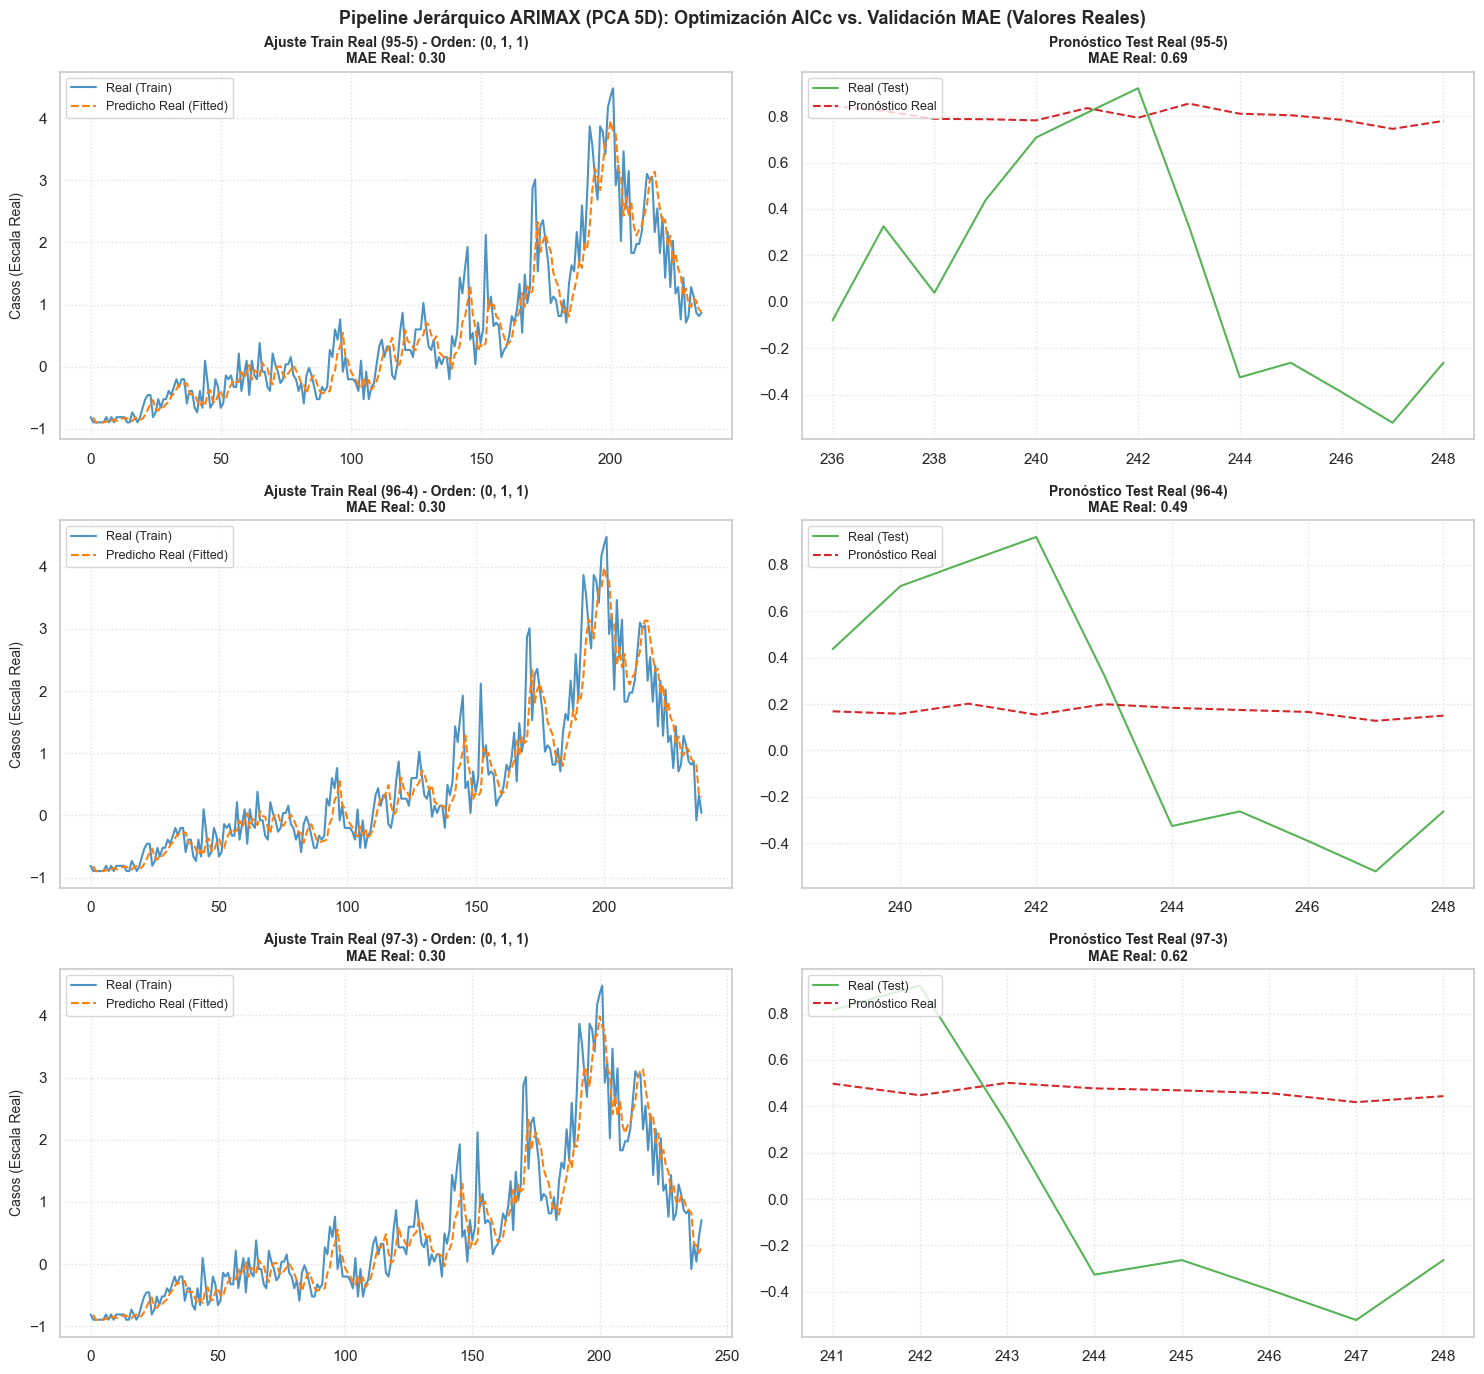


     REPORTE INTEGRAL: ARIMAX EN VALORES REALES (DESHACIENDO LOGP1)      
Partición Orden AICc  AICc Muestra  MAE Train (Real)  MAE Test (Real)
     95-5    (0,1,1)      129.6872            0.3004           0.6892
     96-4    (0,1,1)      133.6701            0.3014           0.4890
     97-3    (0,1,1)      133.9611            0.3017           0.6243


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX

# =============================================================================
# CONFIGURACIÓN DE RUTAS Y PARÁMETROS GLOBALES
# =============================================================================
# Ruta solicitada del archivo con datos procesados por PCA (5 dimensiones)
RUTA_DATA = r"C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\1_reduccion_dimensional\1_pca\2_data\2_precesados\2_datos_meteo_epi_con_rezagos_escalados_con_pca_a_solo_nueve_dimensiones.xlsx"

# =============================================================================
# CARGA DE DATOS Y SELECCIÓN DINÁMICA DE COLUMNAS (Evita KeyError)
# =============================================================================
df = pd.read_excel(RUTA_DATA)

# 1. Definimos la variable objetivo
variable_objetivo = 'casos_ln'

# Verificar que al menos la variable objetivo exista
if variable_objetivo not in df.columns:
    raise KeyError(f"La columna '{variable_objetivo}' no se encuentra en el archivo Excel. Verifica el nombre.")

y = df[variable_objetivo]

# 2. Selección Inteligente de Exógenas:
# Eliminamos 'casos_ln' y cualquier columna de índice/fecha si existiera (ej. 'fecha', 'semana')
columnas_a_excluir = [variable_objetivo, 'fecha', 'semana_epi', 'año']
columnas_exogenas = [col for col in df.columns if col not in columnas_a_excluir]

# Filtramos dinámicamente las 5 dimensiones del PCA estén como estén nombradas
X_exog = df[columnas_exogenas]

print("\n" + "="*50)
print(f"[INFO] Variable objetivo estructurada: '{variable_objetivo}'")
print(f"[INFO] Columnas exógenas detectadas ({len(columnas_exogenas)}): {list(X_exog.columns)}")
print("="*50)

# =============================================================================
# PASO 3: REJILLA DE PARTICIONES TEMPORALES CRONOLÓGICAS (95%, 96%, 97%)
# =============================================================================
particiones = {
    "95-5":  0.95,
    "96-4":  0.96,
    "97-3":  0.97
}

# Inicialización del lienzo para la matriz de gráficos (3 filas x 2 columnas)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 14), sharex=False, sharey=False)
resultados_globales = []

# Bucle iterativo secuencial sobre las ventanas del tiempo
for idx, (nombre_split, tasa_train) in enumerate(particiones.items()):
    print("\n" + "="*75)
    print(f" PROCESAMIENTO JERÁRQUICO ARIMAX: PARTICIÓN CRONOLÓGICA {nombre_split}")
    print("="*75)
    
    # 1. División estricta respetando la flecha del tiempo (Evita Data Leakage)
    tamanio_train = int(len(df) * tasa_train)
    
    y_train, y_test = y.iloc[:tamanio_train], y.iloc[tamanio_train:]
    X_train, X_test = X_exog.iloc[:tamanio_train], X_exog.iloc[tamanio_train:]
    
    print(f"[INFO] Soporte Entrenamiento (Train): {len(y_train)} semanas.")
    print(f"[INFO] Horizonte Pronóstico (Test):     {len(y_test)} semanas.")
    
    # 2. FILTRO 1: Selección de Parámetros óptimos en Train usando criterio AICc (Enfoque ARIMAX)
    print(f"[INFO] Buscando hiperparámetros óptimos (auto_arima ARIMAX) vía AICc...")
    modelo_auto = pm.auto_arima(
        y_train, 
        X=X_train,                
        start_p=2, max_p=5,       
        start_q=1, max_q=3,       
        d=1,                       # Mantenemos la diferenciación regular para estacionariedad
        seasonal=False,            # <--- ARIMAX PURO (Sin estacionalidad SARIMAX)
        stationary=False,
        information_criterion='aicc', 
        error_action='ignore',   
        suppress_warnings=True,  
        stepwise=True             
    )
    
    # Reconstrucción de la estructura matemática ARIMAX ganadora
    p, d_ord, q = modelo_auto.order
    orden_arimax_opt = (p, d_ord, q)
    
    print(f"        -> Estructura determinada por AICc: ARIMAX{orden_arimax_opt}")
    
    # 3. Ajuste formal exacto en Statsmodels
    modelo_final = SARIMAX(
        y_train,
        exog=X_train,
        order=orden_arimax_opt,
        seasonal_order=(0, 0, 0, 0), # <--- Forzado a 0 para garantizar comportamiento ARIMAX
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(method='lbfgs', maxiter=50, disp=False)
    
    # 4. Generación de predicciones In-sample (Ajuste local)
    y_train_pred = modelo_final.fittedvalues
    # Nulos en el primer dato debido a la diferenciación d=1
    y_train_pred.iloc[:1] = np.nan  
    
    # 5. Predicción Dinámica Out-of-sample sobre el Test ciego
    y_test_pred = modelo_final.forecast(steps=len(y_test), exog=X_test)
    
    # =========================================================================
    # TRANSFORMACIÓN INVERSA (logp1 -> Valores Reales de Casos)
    # =========================================================================
    # Aplicamos la función inversa expm1 para recuperar la escala real de contagios/casos
    y_train_real = np.expm1(y_train)
    y_train_pred_real = np.expm1(y_train_pred)
    
    y_test_real = np.expm1(y_test)
    y_test_pred_real = np.expm1(y_test_pred)
    
    # 6. Medida de Desempeño: MAE en la ESCALA REAL
    # Evaluamos ignorando el primer registro por la pérdida de la diferencia d=1
    mae_train_real = mean_absolute_error(y_train_real.dropna()[1:], y_train_pred_real.dropna())
    mae_test_real = mean_absolute_error(y_test_real, y_test_pred_real)
    
    # Archivar los metadatos y métricas del modelo actual
    resultados_globales.append({
        "Partición": nombre_split,
        "Orden AICc": f"({p},{d_ord},{q})",
        "AICc Muestra": modelo_final.aicc,
        "MAE Train (Real)": mae_train_real,
        "MAE Test (Real)": mae_test_real
    })
    
    # =========================================================================
    # PASO 4: GRAFICACIÓN DE LA MATRIZ DE RENDIMIENTO (En Escala Real)
    # =========================================================================
    # Columna 1: Ajuste del Entrenamiento (In-Sample)
    ax_train = axes[idx, 0]
    ax_train.plot(y_train_real.index, y_train_real.values, label='Real (Train)', color='#1f77b4', alpha=0.8)
    ax_train.plot(y_train_pred_real.index, y_train_pred_real.values, label='Predicho Real (Fitted)', color='#ff7f0e', linestyle='--')
    ax_train.set_title(f"Ajuste Train Real ({nombre_split}) - Orden: {orden_arimax_opt}\nMAE Real: {mae_train_real:.2f}", fontsize=10, fontweight='bold')
    ax_train.set_ylabel('Casos (Escala Real)', fontsize=10)
    ax_train.legend(loc='upper left', fontsize=9)
    ax_train.grid(True, linestyle=':', alpha=0.6)
    
    # Columna 2: Pronóstico Fuera de Muestra (Out-of-Sample)
    ax_test = axes[idx, 1]
    ax_test.plot(y_test_real.index, y_test_real.values, label='Real (Test)', color='#2ca02c', alpha=0.8)
    ax_test.plot(y_test_pred_real.index, y_test_pred_real.values, label='Pronóstico Real', color='#d62728', linestyle='--')
    ax_test.set_title(f"Pronóstico Test Real ({nombre_split})\nMAE Real: {mae_test_real:.2f}", fontsize=10, fontweight='bold')
    ax_test.legend(loc='upper left', fontsize=9)
    ax_test.grid(True, linestyle=':', alpha=0.6)

# Estética y visualización de la superestructura gráfica
plt.suptitle('Pipeline Jerárquico ARIMAX (PCA 5D): Optimización AICc vs. Validación MAE (Valores Reales)', 
             fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# =============================================================================
# PASO 5: REPORTE TABULAR DE DESEMPEÑO INTEGRAL
# =============================================================================
df_reporte = pd.DataFrame(resultados_globales)
print("\n" + "="*85)
print("     REPORTE INTEGRAL: ARIMAX EN VALORES REALES (DESHACIENDO LOGP1)      ")
print("="*85)
print(df_reporte.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))
print("="*85)



# Cambios metodológicos clave realizados:

1. **De SARIMAX a ARIMAX:** En `pm.auto_arima` se configuró `seasonal=False`. En la declaración del modelo final `SARIMAX(...)`, el parámetro `seasonal_order` se definió explícitamente como `(0, 0, 0, 0)`. Con esto, la estacionalidad matemática ya no se modela mediante rezagos de largo plazo de la variable endógena, sino que se confía el control de la varianza exógena a las 5 dimensiones calculadas previamente por el PCA.
2. **Corrección del Transitorio Temporal:** Al no haber una diferencia estacional de periodo 52 ($S\_ESTACIONAL$), ya no se pierden las primeras 53 semanas en el set de entrenamiento. La pérdida por diferenciación regular ($d=1$) es de únicamente **1 semana** (`iloc[:1] = np.nan`), lo cual te permite aprovechar casi todo tu histórico para calcular el `MAE Train`.
3. **Escala de las Métricas (MAE Real):** Las variables pasaron por `np.expm1()` antes de restarse. Esto cambia por completo la interpretación del reporte: si tu MAE antes daba `0.15` (en escala logarítmica), ahora el reporte te dirá con exactitud cuántos **casos reales de error (p. ej. $\pm 12$ casos)** está cometiendo el modelo en promedio por semana.

# Evaluar las 5 dimensiones predictoras en el set de testeo 

Para ejecutar el diagnóstico que te sugerí (evaluar si las variables exógenas del PCA se volvieron planas o perdieron variabilidad en el bloque de validación), necesitamos un script que extraiga la matriz $X$ de test para cada una de las tres particiones cronológicas y grafique el comportamiento de las 5 dimensiones.

Aquí tienes el código listo para integrarse a tu flujo de trabajo. Este script replica exactamente tu lógica de particiones (95%, 96%, 97%), aísla el set de test de las exógenas y te genera una matriz visual de comparación.

### Código de Diagnóstico: Análisis de Componentes PCA en Validación



     AUDITORÍA DINÁMICA DE VARIABLES EXÓGENAS (PCA 5D) EN EL SET DE TEST     

[Partición 95-5] Rango de Índices en Test: 236 a 248
-> Varianza promedio de los componentes en este Test: 0.4639

[Partición 96-4] Rango de Índices en Test: 239 a 248
-> Varianza promedio de los componentes en este Test: 0.4562

[Partición 97-3] Rango de Índices en Test: 241 a 248
-> Varianza promedio de los componentes en este Test: 0.3997


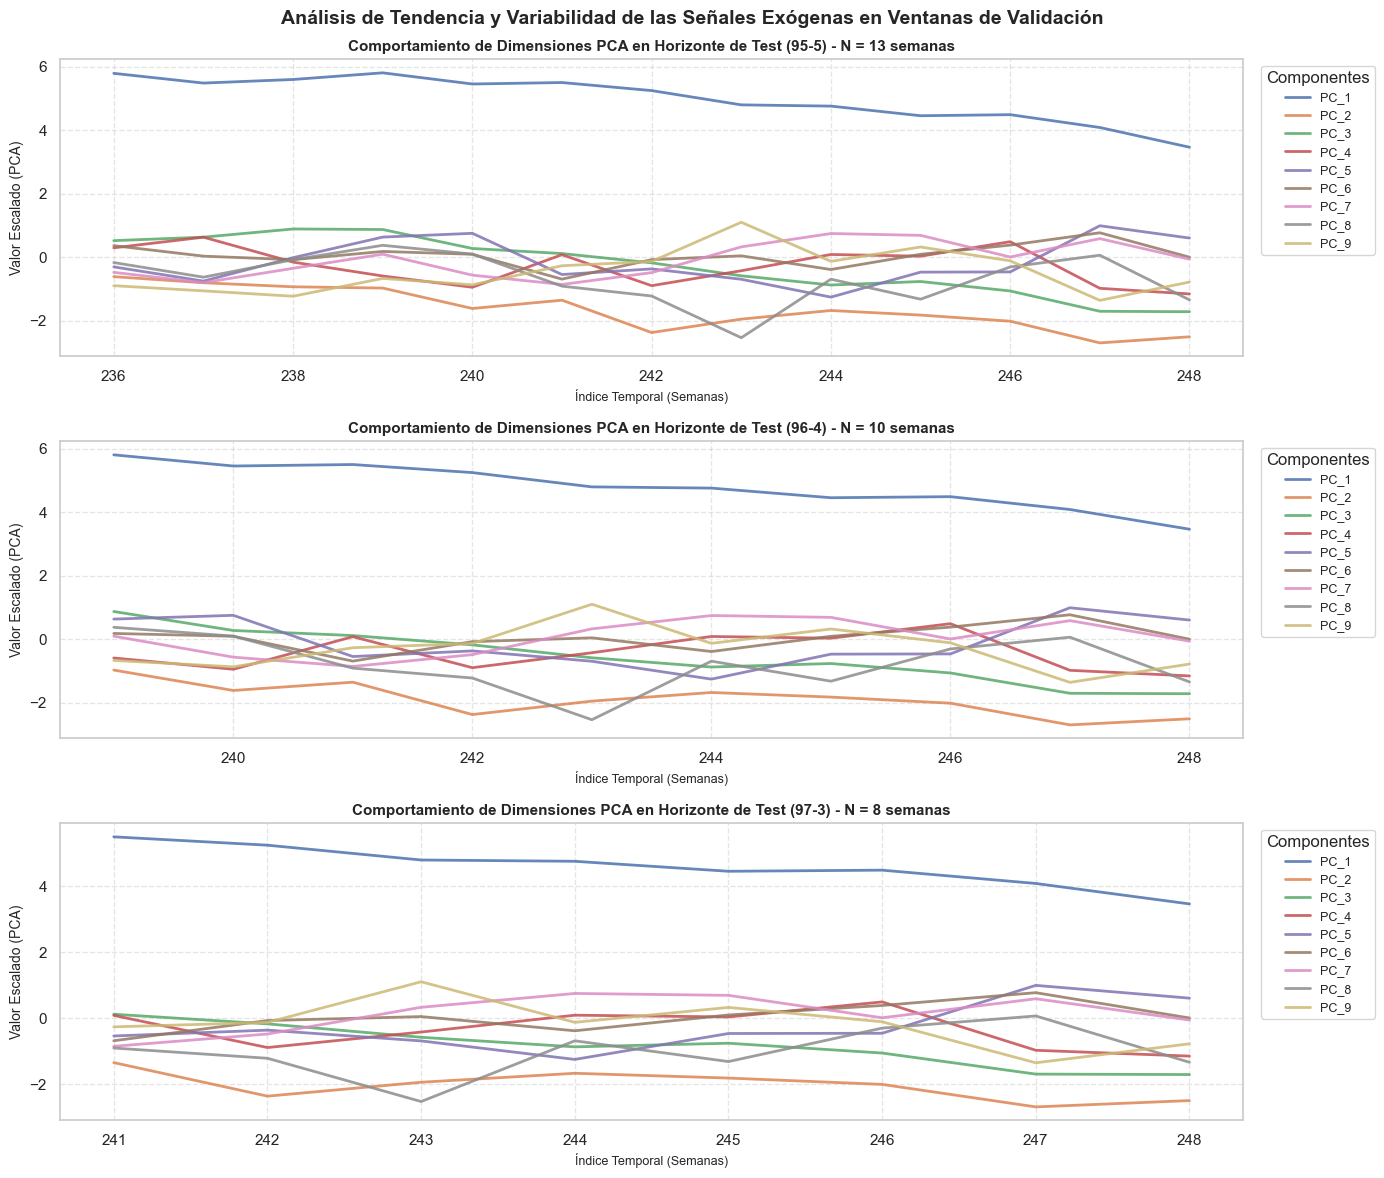

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# INICIALIZACIÓN Y CONFIGURACIÓN DE PARTICIONES (Mismo espejo de tu pipeline)
# =============================================================================
particiones = {
    "95-5":  0.95,
    "96-4":  0.96,
    "97-3":  0.97
}

# Creamos un lienzo de 3 filas (una por partición) y 1 columna
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 12), sharex=False)

print("\n" + "="*80)
print("     AUDITORÍA DINÁMICA DE VARIABLES EXÓGENAS (PCA 5D) EN EL SET DE TEST     ")
print("="*80)

# Bucle cronológico
for idx, (nombre_split, tasa_train) in enumerate(particiones.items()):
    
    # 1. Replicar la división exacta del tiempo
    tamanio_train = int(len(df) * tasa_train)
    X_test = X_exog.iloc[tamanio_train:]
    
    ax = axes[idx]
    
    # 2. Graficar cada una de las 5 dimensiones del PCA en el horizonte de Test
    for columna in X_test.columns:
        ax.plot(X_test.index, X_test[columna], label=str(columna), linewidth=2, alpha=0.85)
    
    # Estadísticos rápidos en consola para auditoría numérica
    print(f"\n[Partición {nombre_split}] Rango de Índices en Test: {X_test.index.min()} a {X_test.index.max()}")
    print(f"-> Varianza promedio de los componentes en este Test: {X_test.var().mean():.4f}")
    
    # 3. Estética de cada subgráfico
    ax.set_title(f"Comportamiento de Dimensiones PCA en Horizonte de Test ({nombre_split}) - N = {len(X_test)} semanas", 
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Valor Escalado (PCA)', fontsize=10)
    ax.set_xlabel('Índice Temporal (Semanas)', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), title="Componentes", fontsize=9)

# Ajuste fino del diseño general
plt.suptitle('Análisis de Tendencia y Variabilidad de las Señales Exógenas en Ventanas de Validación', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()



```

---

### ¿Qué debes buscar al ver los resultados de este gráfico?

Cuando ejecutes este bloque, cruza visualmente estas gráficas con las de los pronósticos planos que obtuviste anteriormente:

1. **Si las líneas del PCA son casi horizontales o estables:** Significa que las variables meteorológicas/epidemiológicas procesadas por el PCA no registraron ningún cambio drástico o anomalía en esas semanas. Por ende, el ARIMAX no tiene "gasolina" exógena para hacer mover la predicción y se apoya solo en su componente inercial autorregresivo.
2. **Si las líneas del PCA muestran fuertes oscilaciones pero el ARIMAX siguió plano:** El problema no son tus datos exógenos, sino la estructura del modelo. Significa que los coeficientes ($\beta$) asignados a tus componentes del PCA durante el entrenamiento son muy cercanos a cero, causando que el modelo ignore las señales climáticas o ambientales en el bloque de test.